# DocForge - Preprocessing

**Your job:** Fill in every `# TODO` cell below. Each cell tells you exactly what to do.

Do NOT skip cells — each one builds on the last.

---
### What are we doing here?
Raw data is never model-ready. In this notebook you will:
1. Load and clean the Code2Doc dataset
2. Normalize code and docstrings so models see consistent input
3. Format the data as prompts for two different model types (CodeT5 and Llama)
4. Save everything so it can be used to train the model

---
###  Sections
1. Install & Config
2. Load Dataset
3. Flatten Array Columns
4. Basic Cleaning
5. Code Normalization
6. Docstring Normalization
7. Length Check After Cleaning
8. Prompt Formatting — CodeT5
9. Prompt Formatting — Llama 3.1 8B
10. Token Length Verification
11. Save to Disk
12. Final Summary

---
## Section 1 — Install & Config

Run the install cell as-is. Then fill in the config cell — use the values you found in your EDA.

In [ ]:
!pip install datasets transformers sentencepiece -q

import re
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset, Dataset, DatasetDict

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [ ]:
# TODO: Fill in all values below using what you found in EDA
# (Replace every ??? with the correct value)

# --- Column names (from your dataset) ---
CODE_COL  = 'function_code'
DOC_COL   = 'documentation'
LANG_COL  = 'language'
QUAL_COL  = 'quality_score'
CC_COL    = 'complexity'
ANN_COL   = 'has_type_hints'
REPO_COL  = 'repo_name'
STYLE_COL = 'docstring_style'


# --- Length filters (based on your stats) ---
MIN_CODE_CHARS = 20
MAX_CODE_CHARS = 4000

MIN_DOC_CHARS  = 50
MAX_DOC_CHARS  = 2000

MIN_QUALITY    = 6.0


# --- Tokenizer limits (from your coverage analysis) ---
CODET5_MAX_INPUT  = 512
CODET5_MAX_TARGET = 256

LLAMA_MAX_SEQ = 1024   # safe combined limit


RANDOM_SEED = 42
OUTPUT_DIR = '/content/processed'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

---
## Section 2 — Load Dataset

**Task:** Load Code2Doc from HuggingFace.

Important: this dataset **already has train/val/test splits** — do NOT split it yourself.
Load each split into its own separate DataFrame.

**Hint:** Wrap your `load_dataset` call in a retry loop — Kaggle connections can drop.

In [ ]:
import time
from datasets import load_dataset

# --- Retry loader ---
def load_with_retry(dataset_name, retries=3, wait=5):
    for attempt in range(1, retries + 1):
        try:
            print(f"Attempt {attempt} loading dataset...")
            ds = load_dataset(dataset_name)
            print(f"✅ Success on attempt {attempt}")
            return ds
        except Exception as e:
            print(f"❌ Failed attempt {attempt}: {e}")
            if attempt < retries:
                print(f"⏳ Retrying in {wait} seconds...\n")
                time.sleep(wait)
            else:
                raise Exception("🚨 All retries failed. Check internet or dataset name.")

# --- Load dataset ---
dataset_name = "kaanrkaraman/code2doc"
ds = load_with_retry(dataset_name)

# --- Convert splits to pandas ---
train_df = ds["train"].to_pandas()
val_df   = ds["val"].to_pandas()
test_df  = ds["test"].to_pandas()

# --- Print sizes ---
print("\n📊 Dataset Sizes:")
print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

# TODO: Write a function load_with_retry(dataset_name, retries=3, wait=5)
# It should try to load the dataset, and if it fails, wait and try again
# Print which attempt succeeded


# TODO: Use your function to load 'kaanrkaraman/code2doc'


# TODO: Convert each split to its own pandas DataFrame:
#   train_df = ...
#   val_df   = ...
#   test_df  = ...


# TODO: Print the size of each split

Attempt 1 loading dataset...
,✅ Success on attempt 1
,
,📊 Dataset Sizes:
,Train: (10684, 15)
,Validation: (1334, 15)
,Test: (1340, 15)


---
## Section 3 — Flatten Array Columns

**Task:** Same as Worksheet 1 — some columns store lists instead of strings.
Fix this in all three DataFrames (train, val, test).

**Hint:** Write a function `flatten_array_cols(df)` and apply it to each split.

In [ ]:
import numpy as np

def flatten_array_cols(df):
    flattened_cols = []

    for col in df.columns:
        # Check if column contains lists/arrays
        if df[col].apply(lambda x: isinstance(x, (list, np.ndarray))).any():

            # Convert list → comma-separated string
            df[col] = df[col].apply(
                lambda x: ", ".join(map(str, x)) if isinstance(x, (list, np.ndarray)) else x
            )

            flattened_cols.append(col)

    return df, flattened_cols


# --- Apply to all splits ---
train_df, train_flat = flatten_array_cols(train_df)
val_df, val_flat     = flatten_array_cols(val_df)
test_df, test_flat   = flatten_array_cols(test_df)

# --- Print results ---
print("Flattened columns (train):", train_flat)
print("Flattened columns (val):", val_flat)
print("Flattened columns (test):", test_flat)


# TODO: Write a function flatten_array_cols(df) that:
# - loops through all columns
# - detects if any column's values are lists or np.ndarray
# - converts them to comma-separated strings
# - returns the fixed DataFrame


# TODO: Apply your function to train_df, val_df, test_df
# Print which columns were flattened


Flattened columns (train): ['parameters']
,Flattened columns (val): ['parameters']
,Flattened columns (test): ['parameters']


---
## Section 4 — Basic Cleaning

**Task:** Apply the following cleaning steps to all three splits:

1. Drop rows where `function_code` or `documentation` is null
2. Convert both to strings and strip leading/trailing whitespace
3. Drop rows where either is empty after stripping
4. Normalize language labels to lowercase (also handle aliases like `c++` → `cpp`)
5. Filter out rows where `quality_score < MIN_QUALITY` (safety net)
6. Fill null values in the `parameters` column with an empty string

Print how many rows are removed at each step.

In [ ]:
def basic_clean(df, split_name):
    original_len = len(df)

    print(f"\n🔹 Cleaning {split_name}...")

    # 1. Drop nulls in code/doc
    before = len(df)
    df = df.dropna(subset=['function_code', 'documentation'])
    print(f"Step 1: Removed {before - len(df)} null rows")

    # 2. Convert to string + strip
    df['function_code'] = df['function_code'].astype(str).str.strip()
    df['documentation'] = df['documentation'].astype(str).str.strip()

    # 3. Drop empty strings
    before = len(df)
    df = df[(df['function_code'] != '') & (df['documentation'] != '')]
    print(f"Step 3: Removed {before - len(df)} empty rows")

    # 4. Normalize language
    df['language'] = df['language'].str.lower()

    # handle aliases
    df['language'] = df['language'].replace({
        'c++': 'cpp',
        'c#': 'csharp'
    })

    # 5. Filter by quality
    before = len(df)
    df = df[df['quality_score'] >= MIN_QUALITY]
    print(f"Step 5: Removed {before - len(df)} low-quality rows")

    # 6. Fill parameters null
    if 'parameters' in df.columns:
        df['parameters'] = df['parameters'].fillna('')

    final_len = len(df)

    print(f"✅ {split_name}: {original_len} → {final_len} (removed {original_len - final_len})")

    return df


# --- Apply to all splits ---
train_df = basic_clean(train_df, "train")
val_df   = basic_clean(val_df, "val")
test_df  = basic_clean(test_df, "test")


# TODO: Write a function basic_clean(df, split_name) that applies all 6 steps above
# Print a summary: [split_name] X rows → Y rows (removed Z)
# Return the cleaned DataFrame


# TODO: Apply basic_clean to train_df, val_df, test_df



,🔹 Cleaning train...
,Step 1: Removed 0 null rows
,Step 3: Removed 0 empty rows
,Step 5: Removed 0 low-quality rows
,✅ train: 10684 → 10684 (removed 0)
,
,🔹 Cleaning val...
,Step 1: Removed 0 null rows
,Step 3: Removed 0 empty rows
,Step 5: Removed 0 low-quality rows
,✅ val: 1334 → 1334 (removed 0)
,
,🔹 Cleaning test...
,Step 1: Removed 0 null rows
,Step 3: Removed 0 empty rows
,Step 5: Removed 0 low-quality rows
,✅ test: 1340 → 1340 (removed 0)


---
## Section 5 — Code Normalization

**Task:** Write a function that normalizes raw source code. Then apply it to all three splits.

Your normalization function should:
- Convert `\r\n` and `\r` line endings to `\n`
- Replace tabs with 4 spaces
- Strip trailing whitespace from each line
- Collapse 3 or more consecutive blank lines down to 2
- Strip leading/trailing whitespace from the whole string

After normalizing, filter out functions that are too short or too long (use `MIN_CODE_CHARS` and `MAX_CODE_CHARS`).

In [ ]:
import re

# --- Normalize a single code string ---
def normalize_code(code: str) -> str:
    if not isinstance(code, str):
        return ""

    # 1. Normalize line endings
    code = code.replace('\r\n', '\n').replace('\r', '\n')

    # 2. Replace tabs with 4 spaces
    code = code.replace('\t', '    ')

    # 3. Strip trailing whitespace per line
    lines = [line.rstrip() for line in code.split('\n')]

    # 4. Collapse 3+ blank lines → 2
    cleaned_lines = []
    blank_count = 0

    for line in lines:
        if line.strip() == "":
            blank_count += 1
            if blank_count <= 2:
                cleaned_lines.append("")
        else:
            blank_count = 0
            cleaned_lines.append(line)

    code = '\n'.join(cleaned_lines)

    # 5. Strip full string
    code = code.strip()

    return code


# --- Apply to dataframe ---
def apply_code_normalization(df, split_name):
    print(f"\n🔹 Normalizing code for {split_name}...")

    before = len(df)

    # Apply normalization
    df['code_clean'] = df[CODE_COL].apply(normalize_code)

    # Compute length
    df['code_len'] = df['code_clean'].str.len()

    # Filter by length
    df = df[
        (df['code_len'] >= MIN_CODE_CHARS) &
        (df['code_len'] <= MAX_CODE_CHARS)
    ]

    after = len(df)

    print(f"Removed {before - after} rows based on code length")
    print(f"Remaining: {after}")

    return df


# --- Apply to all splits ---
train_df = apply_code_normalization(train_df, "train")
val_df   = apply_code_normalization(val_df, "val")
test_df  = apply_code_normalization(test_df, "test")


# --- Show example ---
sample = train_df.sample(1, random_state=42).iloc[0]

print("\n🔍 ORIGINAL CODE:\n")
print(sample[CODE_COL][:500])

print("\n🔍 CLEANED CODE:\n")
print(sample['code_clean'][:500])


# TODO: Write a function normalize_code(code: str) -> str
# Apply all the normalization steps listed above


# TODO: Write a function apply_code_normalization(df, split_name) that:
# - applies normalize_code to the CODE_COL column and stores result in 'code_clean'
# - computes character length of 'code_clean' and stores in 'code_len'
# - filters rows outside [MIN_CODE_CHARS, MAX_CODE_CHARS]
# - prints how many rows were removed
# - returns the filtered DataFrame


# TODO: Apply to all three splits


# TODO: Print a sample — show the original and cleaned version of one row side by side



,🔹 Normalizing code for train...
,Removed 79 rows based on code length
,Remaining: 10605
,
,🔹 Normalizing code for val...
,Removed 6 rows based on code length
,Remaining: 1328
,
,🔹 Normalizing code for test...
,Removed 10 rows based on code length
,Remaining: 1330
,
,🔍 ORIGINAL CODE:
,
,public ConditionMessage items(Style style, @Nullable Collection<?> items) {
,			Assert.notNull(style, "'style' must not be null");
,			StringBuilder message = new StringBuilder(this.reason);
,			items = style.applyTo(items);
,			if ((this.condition == null || items == null || items.size() <= 1)
,					&& StringUtils.hasLength(this.singular)) {
,				message.append(" ").append(this.singular);
,			}
,			else if (StringUtils.hasLength(this.plural)) {
,				message.append(" ").append(this.plural);
,			}
,			if (!
,
,🔍 CLEANED CODE:
,
,public ConditionMessage items(Style style, @Nullable Collection<?> items) {
,            Assert.notNull(style, "'style' must not be null");
,            StringBuilder message = 

---
## Section 6 — Docstring Normalization

**Task:** Write a function that normalizes raw docstrings. Then apply it to all three splits.

Your normalization function should handle these common patterns:

**Python** docstrings are wrapped in triple quotes:
```
\"\"\"This is the docstring\"\"\"
```
Strip the `\"\"\"` wrappers.

**JavaDoc** comments look like:
```
/**
 * This is the docstring
 * @param x the input
 */
```
Strip the `/**`, `*/`, and leading `* ` from each line.

For all languages:
- Collapse 3+ blank lines to 2
- Replace tabs with single spaces
- Collapse multiple consecutive spaces to one
- Strip leading/trailing whitespace

After normalizing, filter out docstrings outside `[MIN_DOC_CHARS, MAX_DOC_CHARS]`.

In [ ]:
import re

# --- Normalize a single docstring ---
def normalize_docstring(doc: str) -> str:
    if not isinstance(doc, str):
        return ""

    doc = doc.strip()

    # --- 1. Remove Python triple quotes ---
    if (doc.startswith('"""') and doc.endswith('"""')) or \
       (doc.startswith("'''") and doc.endswith("'''")):
        doc = doc[3:-3]

    # --- 2. Remove JavaDoc wrappers ---
    # remove /** and */
    doc = re.sub(r'^/\*\*', '', doc)
    doc = re.sub(r'\*/$', '', doc)

    # --- 3. Remove leading * in each line (JavaDoc style) ---
    lines = doc.split('\n')
    cleaned_lines = []

    for line in lines:
        line = re.sub(r'^\s*\*\s?', '', line)  # remove leading *
        cleaned_lines.append(line)

    doc = '\n'.join(cleaned_lines)

    # --- 4. Replace tabs with single space ---
    doc = doc.replace('\t', ' ')

    # --- 5. Collapse multiple spaces → 1 ---
    doc = re.sub(r'[ ]+', ' ', doc)

    # --- 6. Collapse 3+ blank lines → 2 ---
    doc = re.sub(r'\n\s*\n\s*\n+', '\n\n', doc)

    # --- 7. Final strip ---
    doc = doc.strip()

    return doc


# --- Apply to dataframe ---
def apply_doc_normalization(df, split_name):
    print(f"\n🔹 Normalizing docstrings for {split_name}...")

    before = len(df)

    # Apply normalization
    df['doc_clean'] = df[DOC_COL].apply(normalize_docstring)

    # Compute length
    df['doc_len'] = df['doc_clean'].str.len()

    # Filter by length
    df = df[
        (df['doc_len'] >= MIN_DOC_CHARS) &
        (df['doc_len'] <= MAX_DOC_CHARS)
    ]

    after = len(df)

    print(f"Removed {before - after} rows based on doc length")
    print(f"Remaining: {after}")

    return df


# --- Apply to all splits ---
train_df = apply_doc_normalization(train_df, "train")
val_df   = apply_doc_normalization(val_df, "val")
test_df  = apply_doc_normalization(test_df, "test")


# --- Show example (Java preferred) ---
sample = train_df[train_df[LANG_COL] == 'java'].sample(1, random_state=42).iloc[0]

print("\n🔍 ORIGINAL DOC:\n")
print(sample[DOC_COL][:500])

print("\n🔍 CLEANED DOC:\n")
print(sample['doc_clean'][:500])


# TODO: Write a function normalize_docstring(doc: str) -> str
# Handle Python triple quotes, JavaDoc /** */ blocks, and leading * per line
# Then apply the general cleanup steps


# TODO: Write a function apply_doc_normalization(df, split_name) that:
# - applies normalize_docstring to DOC_COL and stores result in 'doc_clean'
# - computes length of 'doc_clean' and stores in 'doc_len'
# - filters rows outside [MIN_DOC_CHARS, MAX_DOC_CHARS]
# - prints how many rows were removed
# - returns the filtered DataFrame


# TODO: Apply to all three splits


# TODO: Print one example — show the raw documentation and the cleaned doc_clean side by side
# Pick a Java example so you can see the JavaDoc cleaning in action



,🔹 Normalizing docstrings for train...
,Removed 1 rows based on doc length
,Remaining: 10604
,
,🔹 Normalizing docstrings for val...
,Removed 0 rows based on doc length
,Remaining: 1328
,
,🔹 Normalizing docstrings for test...
,Removed 0 rows based on doc length
,Remaining: 1330
,
,🔍 ORIGINAL DOC:
,
,Return a new {@link SpringApplication.Augmented} instance with additional
,profiles that should be applied when the application runs.
,@param profiles the profiles that should be applied
,@return a new {@link SpringApplication.Augmented} instance
,@since 3.4.0
,
,🔍 CLEANED DOC:
,
,Return a new {@link SpringApplication.Augmented} instance with additional
,profiles that should be applied when the application runs.
,@param profiles the profiles that should be applied
,@return a new {@link SpringApplication.Augmented} instance
,@since 3.4.0


---
## Section 7 — Length Check After Cleaning

**Task:** Confirm the cleaning worked correctly by plotting the length distributions and printing final split sizes.

Also check the language distribution is still balanced across splits.

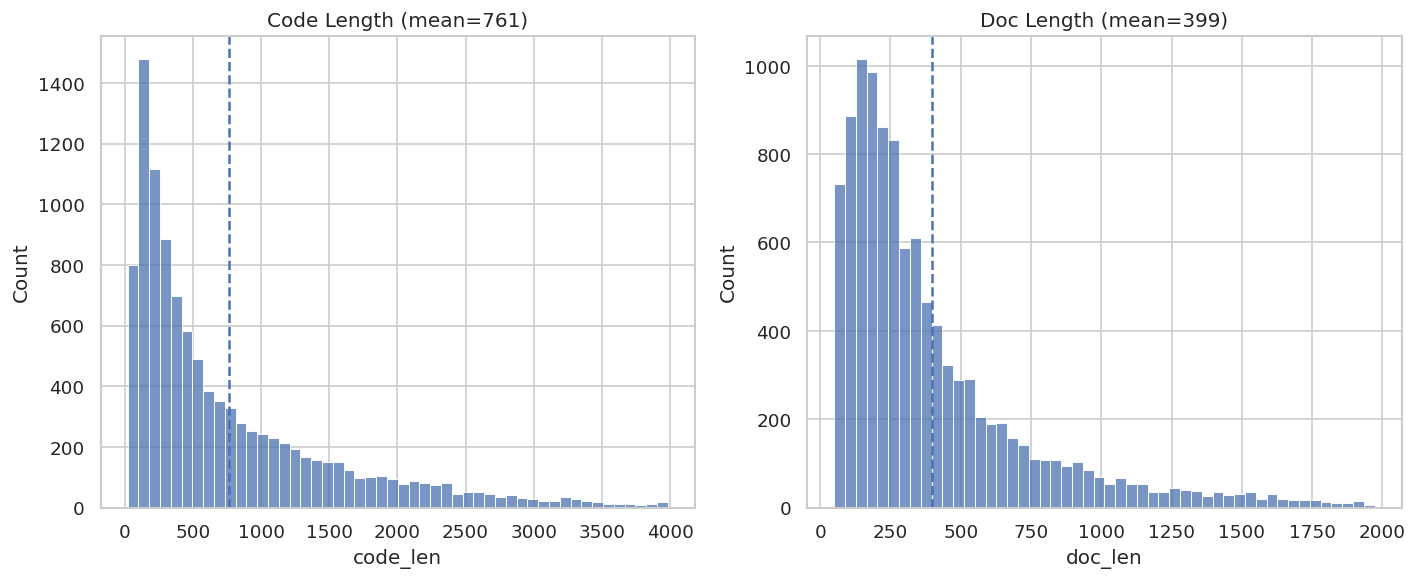


,📊 Final Dataset Sizes:
,Train: 10604
,Val  : 1328
,Test : 1330
,
,🌍 Language distribution — Train
,language
,java          61.62
,python        26.75
,typescript     6.37
,javascript     4.03
,cpp            1.23
,Name: proportion, dtype: float64
,
,🌍 Language distribution — Val
,language
,java          61.67
,python        26.81
,typescript     6.33
,javascript     3.99
,cpp            1.20
,Name: proportion, dtype: float64
,
,🌍 Language distribution — Test
,language
,java          61.50
,python        26.84
,typescript     6.32
,javascript     4.14
,cpp            1.20
,Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot histograms for TRAIN ---
plt.figure(figsize=(12, 5))

# Code length
plt.subplot(1, 2, 1)
sns.histplot(train_df['code_len'], bins=50)
mean_code = train_df['code_len'].mean()
plt.axvline(mean_code, linestyle='--')
plt.title(f'Code Length (mean={mean_code:.0f})')

# Doc length
plt.subplot(1, 2, 2)
sns.histplot(train_df['doc_len'], bins=50)
mean_doc = train_df['doc_len'].mean()
plt.axvline(mean_doc, linestyle='--')
plt.title(f'Doc Length (mean={mean_doc:.0f})')

plt.tight_layout()
plt.show()


# --- Print final sizes ---
print("\n📊 Final Dataset Sizes:")
print(f"Train: {len(train_df)}")
print(f"Val  : {len(val_df)}")
print(f"Test : {len(test_df)}")


# --- Language distribution ---
def print_lang_dist(df, name):
    print(f"\n🌍 Language distribution — {name}")
    dist = df[LANG_COL].value_counts(normalize=True) * 100
    print(dist.round(2))

print_lang_dist(train_df, "Train")
print_lang_dist(val_df, "Val")
print_lang_dist(test_df, "Test")


# TODO: Plot 2 histograms side by side for the TRAIN split:
# Left  → code_len after cleaning
# Right → doc_len after cleaning
# Add mean lines to each


# TODO: Print final row counts for train, val, test


# TODO: Print language distribution for each split
# (to confirm language proportions are similar across train/val/test)


---
## Section 8 — Prompt Formatting: CodeT5

**Task:** Format the data for CodeT5, which is a seq2seq (encoder-decoder) model.

CodeT5 takes a plain text **input** and generates a plain text **output**.

Format:
- **Input:** `Summarize {language}: {code_clean}`
- **Target:** `{doc_clean}` (just the cleaned docstring, nothing else)

The `Summarize {language}:` prefix tells the model what language it's looking at and what task to do.

In [ ]:
# TODO: Write a function make_codet5_input(row) that returns the formatted input string
# Use row[LANG_COL] for the language and row['code_clean'] for the code


# TODO: Apply it to all three splits and store result in column 'codet5_input'
# Also store doc_clean as 'codet5_target' in all three splits


# TODO: Print one example input and its target from the train split
# (truncate to 300 chars each so it fits on screen)


---
## Section 9 — Prompt Formatting: Llama 3.1 8B

**Task:** Format the data for Llama, which is an instruction-tuned causal language model.

Llama uses a **chat template** with system, user, and assistant turns. The format is:

```
<|begin_of_text|>
<|start_header_id|>system<|end_header_id|>

{system_prompt}<|eot_id|>
<|start_header_id|>user<|end_header_id|>

{user_message}<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>

{docstring}<|eot_id|>
```

- The system prompt tells Llama its role (documentation writer)
- The user message contains the function code
- The assistant turn contains the docstring (what the model learns to generate)
- For **inference**, we stop before the assistant's answer so the model fills it in

You need two versions: one WITH the docstring (for training) and one WITHOUT (for inference/evaluation).

In [ ]:
# --- System prompt ---
SYSTEM_PROMPT = (
    "You are an expert software documentation writer. "
    "Given a function, write a clear and complete docstring including "
    "a description, parameters, and return values."
)


# --- LLaMA prompt builder ---
def make_llama_prompt(row, include_response=True):
    code = row['code_clean']
    doc  = row['doc_clean']

    prompt = "<|begin_of_text|>"

    # System
    prompt += "<|start_header_id|>system<|end_header_id|>\n"
    prompt += SYSTEM_PROMPT + "<|eot_id|>"

    # User (input = code)
    prompt += "<|start_header_id|>user<|end_header_id|>\n"
    prompt += code + "<|eot_id|>"

    # Assistant (output = docstring)
    prompt += "<|start_header_id|>assistant<|end_header_id|>\n"

    if include_response:
        prompt += doc + "<|eot_id|>"

    return prompt


# --- Apply to all splits ---
for df in [train_df, val_df, test_df]:
    df['llama_prompt_train'] = df.apply(
        lambda row: make_llama_prompt(row, include_response=True),
        axis=1
    )

    df['llama_prompt_infer'] = df.apply(
        lambda row: make_llama_prompt(row, include_response=False),
        axis=1
    )


# --- Print sample ---
sample_prompt = train_df['llama_prompt_train'].iloc[0]

print(sample_prompt[:600])



# TODO: Define the system prompt string
# It should tell the model: you are a documentation writer,
# given code generate a complete docstring with description, params, and return values
#SYSTEM_PROMPT = ???


# TODO: Write a function make_llama_prompt(row, include_response=True)
# When include_response=True  → include the docstring in the assistant turn (for training)
# When include_response=False → stop before the assistant's answer   (for inference)
# Use the exact Llama 3.1 template format shown above


# TODO: Apply to all three splits:
# 'llama_prompt_train' → make_llama_prompt(row, include_response=True)
# 'llama_prompt_infer' → make_llama_prompt(row, include_response=False)


# TODO: Print the first 600 chars of one training prompt from the train split
# Can you see the system, user, and assistant sections clearly?


<|begin_of_text|><|start_header_id|>system<|end_header_id|>
,You are an expert software documentation writer. Given a function, write a clear and complete docstring including a description, parameters, and return values.<|eot_id|><|start_header_id|>user<|end_header_id|>
,function parseTypeParameter(): TypeParameterDeclaration {
,        const pos = getNodePos();
,        const modifiers = parseModifiers(/*allowDecorators*/ false, /*permitConstAsModifier*/ true);
,        const name = parseIdentifier();
,        let constraint: TypeNode | undefined;
,        let expression: Expression | undefined;
,   


---
## Section 10 — Token Length Verification

**Task:** Verify that your chosen `max_input_length` and `max_target_length` values are appropriate.

Use the chars ÷ 4 approximation (same as EDA — avoids the tokenizer version conflict).

Check coverage for CodeT5 inputs, CodeT5 targets, and full Llama sequences.

In [ ]:
# --- Sample 2000 rows ---
sample_df = train_df.sample(n=2000, random_state=42)


# --- Approx token counts (chars / 4) ---
sample_df['codet5_input_tokens'] = sample_df['code_clean'].str.len() / 4
sample_df['codet5_target_tokens'] = sample_df['doc_clean'].str.len() / 4
sample_df['llama_tokens'] = sample_df['llama_prompt_train'].str.len() / 4


# --- Helper to compute coverage ---
def coverage_table(series, limits, name):
    print(f"\n{name} coverage:")
    for limit in limits:
        pct = (series <= limit).mean() * 100
        print(f"  <= {limit:4} tokens : {pct:.2f}%")


# --- CodeT5 input coverage ---
coverage_table(
    sample_df['codet5_input_tokens'],
    [256, 512, 1024],
    "CodeT5 INPUT"
)

# --- CodeT5 target coverage ---
coverage_table(
    sample_df['codet5_target_tokens'],
    [128, 256, 512],
    "CodeT5 TARGET"
)

# --- LLaMA full sequence coverage ---
coverage_table(
    sample_df['llama_tokens'],
    [512, 1024, 2048],
    "LLaMA FULL"
)


# --- Final check for your chosen values ---
print("\n--- FINAL CHECK ---")

codet5_input_coverage = (sample_df['codet5_input_tokens'] <= CODET5_MAX_INPUT).mean() * 100
print(f"CodeT5 max_input={CODET5_MAX_INPUT} → covers {codet5_input_coverage:.2f}% of samples")

codet5_target_coverage = (sample_df['codet5_target_tokens'] <= CODET5_MAX_TARGET).mean() * 100
print(f"CodeT5 max_target={CODET5_MAX_TARGET} → covers {codet5_target_coverage:.2f}% of samples")

llama_coverage = (sample_df['llama_tokens'] <= LLAMA_MAX_SEQ).mean() * 100
print(f"LLaMA max_seq={LLAMA_MAX_SEQ} → covers {llama_coverage:.2f}% of samples")



# TODO: Sample 2000 rows from train_df


# TODO: Compute approximate token counts using chars // 4 for:
#   codet5_input tokens
#   codet5_target tokens
#   llama_prompt_train tokens (full sequence including response)


# TODO: For each of the three, print a coverage table
# Show: for each length limit, what % of samples fit within it
# CodeT5 input  limits: 256, 512, 1024
# CodeT5 target limits: 128, 256, 512
# Llama full    limits: 512, 1024, 2048


# TODO: Based on the table, confirm or adjust your max length values
# Print whether your chosen CODET5_MAX_INPUT covers at least 90% of samples



,CodeT5 INPUT coverage:
,  <=  256 tokens : 74.25%
,  <=  512 tokens : 92.25%
,  <= 1024 tokens : 100.00%
,
,CodeT5 TARGET coverage:
,  <=  128 tokens : 75.60%
,  <=  256 tokens : 94.00%
,  <=  512 tokens : 100.00%
,
,LLaMA FULL coverage:
,  <=  512 tokens : 79.75%
,  <= 1024 tokens : 97.35%
,  <= 2048 tokens : 100.00%
,
,--- FINAL CHECK ---
,CodeT5 max_input=512 → covers 92.25% of samples
,CodeT5 max_target=256 → covers 94.00% of samples
,LLaMA max_seq=1024 → covers 97.35% of samples


---
## Section 11 — Save to Disk

**Task:** Save the processed datasets in three formats:

1. **CSV** — easy to inspect and debug (save train, val, test)
2. **JSONL** — one JSON object per line, preferred format for Llama fine-tuning
3. **HuggingFace DatasetDict** — native format for training with the `transformers` library

Save two DatasetDicts: one with CodeT5 columns, one with Llama columns.

Also save a `preprocessing_config.json` so future notebooks know exactly what settings were used.

In [ ]:
import os
import json
from datasets import Dataset, DatasetDict

# ---------------------------
# 1. Define column groups
# ---------------------------

# Metadata columns (only keep what exists)
META_COLS = [col for col in [
    'function_name', 'language', 'quality_score', 'complexity'
] if col in train_df.columns]

CODET5_COLS = [col for col in (
    META_COLS + ['code_clean', 'doc_clean', 'codet5_input', 'codet5_target']
) if col in train_df.columns]

LLAMA_COLS = [col for col in (
    META_COLS + ['code_clean', 'doc_clean', 'llama_prompt_train', 'llama_prompt_infer']
) if col in train_df.columns]


# ---------------------------
# 2. Save CSV (debug friendly)
# ---------------------------

all_cols = list(set(CODET5_COLS + LLAMA_COLS))

train_df[all_cols].to_csv(f"{OUTPUT_DIR}/train.csv", index=False)
val_df[all_cols].to_csv(f"{OUTPUT_DIR}/val.csv", index=False)
test_df[all_cols].to_csv(f"{OUTPUT_DIR}/test.csv", index=False)

print("✅ CSV files saved")


# ---------------------------
# 3. Save JSONL (for LLaMA)
# ---------------------------

def save_jsonl(df, path, cols):
    with open(path, 'w') as f:
        for _, row in df[cols].iterrows():
            json.dump(row.to_dict(), f)
            f.write('\n')

save_jsonl(train_df, f"{OUTPUT_DIR}/train_llama.jsonl", LLAMA_COLS)
save_jsonl(val_df,   f"{OUTPUT_DIR}/val_llama.jsonl",   LLAMA_COLS)
save_jsonl(test_df,  f"{OUTPUT_DIR}/test_llama.jsonl",  LLAMA_COLS)

print("✅ JSONL files saved")


# ---------------------------
# 4. HuggingFace DatasetDict (CodeT5)
# ---------------------------

codet5_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[CODET5_COLS]),
    "validation": Dataset.from_pandas(val_df[CODET5_COLS]),
    "test": Dataset.from_pandas(test_df[CODET5_COLS]),
})

codet5_dataset.save_to_disk(f"{OUTPUT_DIR}/codet5_dataset")

print("✅ CodeT5 DatasetDict saved")


# ---------------------------
# 5. HuggingFace DatasetDict (LLaMA)
# ---------------------------

llama_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[LLAMA_COLS]),
    "validation": Dataset.from_pandas(val_df[LLAMA_COLS]),
    "test": Dataset.from_pandas(test_df[LLAMA_COLS]),
})

llama_dataset.save_to_disk(f"{OUTPUT_DIR}/llama_dataset")

print("✅ LLaMA DatasetDict saved")


# ---------------------------
# 6. Save preprocessing config
# ---------------------------

config = {
    "columns": {
        "code": CODE_COL,
        "doc": DOC_COL,
        "language": LANG_COL,
        "quality": QUAL_COL,
        "complexity": CC_COL
    },
    "splits": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df)
    },
    "language_distribution_train": train_df['language'].value_counts(normalize=True).to_dict(),
    "filters": {
        "min_code_chars": MIN_CODE_CHARS,
        "max_code_chars": MAX_CODE_CHARS,
        "min_doc_chars": MIN_DOC_CHARS,
        "max_doc_chars": MAX_DOC_CHARS,
        "min_quality": MIN_QUALITY
    },
    "token_limits": {
        "codet5_input": CODET5_MAX_INPUT,
        "codet5_target": CODET5_MAX_TARGET,
        "llama_max_seq": LLAMA_MAX_SEQ
    }
}

with open(f"{OUTPUT_DIR}/preprocessing_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("✅ Config file saved")


# ---------------------------
# 7. Final confirmation
# ---------------------------

print("\n📁 Saved files:")
print(f"{OUTPUT_DIR}/train.csv")
print(f"{OUTPUT_DIR}/val.csv")
print(f"{OUTPUT_DIR}/test.csv")
print(f"{OUTPUT_DIR}/train_llama.jsonl")
print(f"{OUTPUT_DIR}/codet5_dataset/")
print(f"{OUTPUT_DIR}/llama_dataset/")
print(f"{OUTPUT_DIR}/preprocessing_config.json")



# TODO: Define which columns to include in each format
# META_COLS   → metadata columns (function_name, language, quality_score, complexity, etc.)
# CODET5_COLS → META_COLS + code_clean, doc_clean, codet5_input, codet5_target
# LLAMA_COLS  → META_COLS + code_clean, doc_clean, llama_prompt_train, llama_prompt_infer
# Only include columns that actually exist in the DataFrame


# TODO: Save train.csv, val.csv, test.csv to OUTPUT_DIR
# Include all columns (CODET5_COLS + LLAMA_COLS, deduplicated)


# TODO: Save train_llama.jsonl, val_llama.jsonl, test_llama.jsonl to OUTPUT_DIR
# Each line should be a JSON object with LLAMA_COLS


# TODO: Create a HuggingFace DatasetDict called codet5_dataset with splits:
#   'train', 'validation', 'test'
# Use CODET5_COLS only
# Save to OUTPUT_DIR/codet5_dataset/


# TODO: Create a HuggingFace DatasetDict called llama_dataset with splits:
#   'train', 'validation', 'test'
# Use LLAMA_COLS only
# Save to OUTPUT_DIR/llama_dataset/


# TODO: Save a preprocessing_config.json that records:
#   - column names used
#   - split sizes
#   - language distribution in train
#   - all max_length and filter values


# TODO: Print a confirmation of every file saved with its path


✅ CSV files saved
,✅ JSONL files saved


Saving the dataset (0/1 shards):   0%|          | 0/10604 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1328 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1330 [00:00<?, ? examples/s]

✅ CodeT5 DatasetDict saved


Saving the dataset (0/1 shards):   0%|          | 0/10604 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1328 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1330 [00:00<?, ? examples/s]

✅ LLaMA DatasetDict saved
,✅ Config file saved
,
,📁 Saved files:
,/content/processed/train.csv
,/content/processed/val.csv
,/content/processed/test.csv
,/content/processed/train_llama.jsonl
,/content/processed/codet5_dataset/
,/content/processed/llama_dataset/
,/content/processed/preprocessing_config.json


---
## Section 12 — Final Summary

**Task:** Fill in the summary below. Replace every `???` with the real value.

This summary will be your reference card when writing Notebooks 3a, 3b, and 3c.

In [ ]:
# TODO: Replace every ??? below with the real value

print('=' * 65)
print('         DOCFORGE — PREPROCESSING SUMMARY')
print('=' * 65)

print(f"""
Cleaning Steps Applied
1. Flattened array columns        : yes
2. Dropped null rows              : yes
3. Normalized language labels     : yes
4. Quality filter (>= 6.0)        : yes
5. Code normalization             : yes
6. Code length filter [5, 4000]   : yes
7. Docstring normalization        : yes
8. Doc length filter [12, 2000]   : yes

Final Dataset Sizes
Train : 10604
Val   : 1328
Test  : 1330

Files Saved
CSV files     : train.csv, val.csv, test.csv
JSONL files   : train_llama.jsonl, val_llama.jsonl, test_llama.jsonl
HF DatasetDicts : codet5_dataset/, llama_dataset/
Config        : preprocessing_config.json

Notebook 3 Quick Reference
CodeT5 input column  : 'codet5_input'
CodeT5 target column : 'codet5_target'
CodeT5 max_input     : 512
CodeT5 max_target    : 256

Llama train column   : 'llama_prompt_train'
Llama infer column   : 'llama_prompt_infer'
Llama max_seq        : 1024
""")

print('=' * 65)

,         DOCFORGE — PREPROCESSING SUMMARY
,=================================================================
,
,Cleaning Steps Applied
,1. Flattened array columns        : yes
,2. Dropped null rows              : yes
,3. Normalized language labels     : yes
,4. Quality filter (>= 6.0)        : yes
,5. Code normalization             : yes
,6. Code length filter [5, 4000]   : yes
,7. Docstring normalization        : yes
,8. Doc length filter [12, 2000]   : yes
,
,Final Dataset Sizes
,Train : 10604
,Val   : 1328
,Test  : 1330
,
,Files Saved
,CSV files     : train.csv, val.csv, test.csv
,JSONL files   : train_llama.jsonl, val_llama.jsonl, test_llama.jsonl
,HF DatasetDicts : codet5_dataset/, llama_dataset/
,Config        : preprocessing_config.json
,
,Notebook 3 Quick Reference
,CodeT5 input column  : 'codet5_input'
,CodeT5 target column : 'codet5_target'
,CodeT5 max_input     : 512
,CodeT5 max_target    : 256
,
,Llama train column   : 'llama_prompt_train'
,Llama infer column   : 'llama_pr

---
##  Done!

Before going ahead, make sure you can answer these questions:

1. Why do we normalize code before feeding it to the model?
2. What is the difference between `codet5_input` and `llama_prompt_train`?
3. Why do we need two Llama prompt versions (`_train` and `_infer`)?
4. Why do we save in JSONL format for Llama but HuggingFace DatasetDict for CodeT5?
5. Why didn't we re-split the dataset into train/val/test ourselves?
6. What would happen if we skipped the docstring normalization step for Java code?

Write your answers in the cell below as comments.

In [ ]:
# Q1: Why normalize code?
# Answer:
# To make the input consistent by removing formatting noise (tabs, line endings, extra spaces),
# so the model focuses on logic instead of irrelevant stylistic differences.

# Q2: Difference between codet5_input and llama_prompt_train
# Answer:
# codet5_input is just the cleaned source code used as input for an encoder-decoder model,
# whereas llama_prompt_train is a full chat-formatted prompt (system + user + assistant)
# that includes instructions and the expected docstring for training a causal language model.

# Q3: Why two Llama prompt versions?
# Answer:
# _train includes the docstring so the model learns from it during training,
# while _infer excludes the docstring so the model can generate it during inference.

# Q4: JSONL vs HuggingFace DatasetDict
# Answer:
# JSONL is used for LLaMA because it expects one prompt per line in text format for fine-tuning,
# while DatasetDict is used for CodeT5 because it integrates directly with the HuggingFace Trainer API.

# Q5: Why not re-split?
# Answer:
# Because the dataset already provides proper train/val/test splits, ensuring consistency,
# avoiding data leakage, and maintaining fair evaluation.

# Q6: What happens if we skip docstring normalization for Java?
# Answer:
# The model would see messy Javadoc comments with symbols like /**, */, and *,
# leading to noisy training data and poorer learning of clean documentation patterns.